<a href="https://colab.research.google.com/github/Nikralet/General/blob/main/%D0%9B%D0%90%D0%91%D0%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np                    # библиотека для работы с массивами и математикой
from scipy.integrate import odeint   # функция интегрирования ОДУ
import matplotlib.pyplot as plt      # построение графиков

# =============================================================================
# МОДЕЛЬ БЕЗ ЁМКОСТИ (β_c = 0) – для быстрых карт выпрямления
# =============================================================================
def aqfp_rhs(state, t, params):
    """
    Правая часть системы ОДУ для AQFP без учёта ёмкости (β_c = 0).
    state = [phi1, phi2] – фазы на переходах J1, J2
    t – текущее безразмерное время (в единицах τ_c)
    params – кортеж параметров: (beta_L, beta_q, Ax, omega, phi_dc, phi_in)
    """
    phi1, phi2 = state                # распаковка фаз
    beta_L, beta_q, Ax, omega, phi_dc, phi_in = params   # распаковка параметров
    phi_x = Ax * np.sin(omega * t) + phi_dc               # мгновенное значение нормированного тока возбуждения
    # Первый закон Кирхгофа + RCSJ (без ёмкости) дают уравнения:
    dphi1 = -np.sin(phi1) - (phi1 - phi_x)/beta_L - (phi1 - phi2 - phi_in)/beta_q
    dphi2 = -np.sin(phi2) - (phi2 + phi_x)/beta_L + (phi1 - phi2 - phi_in)/beta_q
    return [dphi1, dphi2]              # возвращаем производные фаз

def simulate_and_average(params, n_periods=60, n_points=200, transient=0.3):
    """
    Интегрирование модели без ёмкости и вычисление среднего выходного тока.
    params – параметры (beta_L, beta_q, Ax, omega, phi_dc, phi_in)
    n_periods – количество периодов возбуждения
    n_points – точек на один период
    transient – доля времени, отбрасываемая как переходный процесс (0.3 = 30%)
    """
    beta_L, beta_q, Ax, omega, phi_dc, phi_in = params
    T = 2 * np.pi / omega              # период синусоидального возбуждения
    t_max = n_periods * T              # полное время интегрирования
    t_eval = np.linspace(0, t_max, n_periods * n_points)  # массив моментов времени
    y0 = [0.0, 0.0]                    # начальные условия: нулевые фазы
    sol = odeint(aqfp_rhs, y0, t_eval, args=(params,), rtol=1e-6, atol=1e-8)  # решение ОДУ
    phi1_arr, phi2_arr = sol[:, 0], sol[:, 1]   # извлекаем массивы фаз
    iq_arr = (phi1_arr - phi2_arr - phi_in) / beta_q  # выходной ток в каждый момент времени
    n_trans = int(transient * len(t_eval))   # индекс конца переходного процесса
    return np.mean(iq_arr[n_trans:])         # среднее значение по установившемуся режиму

# =============================================================================
# РАСШИРЕННАЯ МОДЕЛЬ С ЁМКОСТЬЮ (β_c > 0) – для финальной оптимизации
# =============================================================================
def aqfp_rhs_c(state, t, params):
    """
    Правая часть системы ОДУ для AQFP с учётом ёмкости (β_c > 0).
    state = [phi1, phi2, p1, p2] – фазы и их производные (импульсы)
    """
    phi1, phi2, p1, p2 = state
    beta_L, beta_q, beta_c, Ax, omega, phi_dc, phi_in = params
    phi_x = Ax * np.sin(omega * t) + phi_dc
    # Уравнения второго порядка: dφ/dt = p, dp/dt = ... (RCSJ + индуктивности)
    dphi1 = p1
    dphi2 = p2
    dp1 = (-p1 - np.sin(phi1) - (phi1 - phi_x)/beta_L - (phi1 - phi2 - phi_in)/beta_q) / beta_c
    dp2 = (-p2 - np.sin(phi2) - (phi2 + phi_x)/beta_L + (phi1 - phi2 - phi_in)/beta_q) / beta_c
    return [dphi1, dphi2, dp1, dp2]

def simulate_and_average_c(params, n_periods=50, n_points=200, transient=0.3):
    """
    Интегрирование расширенной модели и вычисление среднего i_q.
    """
    beta_L, beta_q, beta_c, Ax, omega, phi_dc, phi_in = params
    T = 2 * np.pi / omega
    t_max = n_periods * T
    t_eval = np.linspace(0, t_max, n_periods * n_points)
    y0 = [0.0, 0.0, 0.0, 0.0]           # нулевые начальные фазы и импульсы
    sol = odeint(aqfp_rhs_c, y0, t_eval, args=(params,), rtol=1e-6, atol=1e-8)
    phi1_arr, phi2_arr = sol[:, 0], sol[:, 1]
    iq_arr = (phi1_arr - phi2_arr - phi_in) / beta_q
    n_trans = int(transient * len(t_eval))
    return np.mean(iq_arr[n_trans:])

# =============================================================================
# ГРАДИЕНТНЫЙ СПУСК
# =============================================================================
def gradient_descent(params_init, lr=0.03, delta=0.05, max_iter=100, tol=1e-4):
    """
    Оптимизация параметров β_L, β_q, β_c (индексы 0,1,2) для максимизации |<iq>|.
    A_x, ω, φ_dc, φ_in – фиксированы.
    Используется метод конечных разностей для градиента.
    """
    params = np.array(params_init, dtype=float)   # рабочий массив параметров
    var_idx = [0, 1, 2]                           # индексы варьируемых параметров
    labels = ['β_L', 'β_q', 'β_c']                # для вывода

    # Фиксированные значения (выбраны на основе карты выпрямления)
    fixed_Ax = 1.5
    fixed_phi_dc = 0.1
    fixed_omega = 0.1
    fixed_phi_in = 0.0

    def objective(var_vals):
        """Целевая функция: -|средний ток|. Минимизация максимизирует модуль."""
        p = params.copy()
        for i, idx in enumerate(var_idx):
            p[idx] = var_vals[i]               # подставляем варьируемые значения
        p[3] = fixed_Ax
        p[4] = fixed_omega
        p[5] = fixed_phi_dc
        p[6] = fixed_phi_in
        try:
            mean_val = simulate_and_average_c(tuple(p), n_periods=60)  # расчёт среднего
            if np.isnan(mean_val) or np.isinf(mean_val):
                return 1e6                     # штраф за некорректное значение
            return -abs(mean_val)              # отрицательный модуль для минимизации
        except Exception:
            return 1e6                         # штраф при ошибке интегрирования

    history = []                                # список для записи |<iq>| на каждой итерации
    for it in range(max_iter):
        cur = np.array([params[i] for i in var_idx])   # текущие значения варьируемых параметров
        val = objective(cur)                           # значение целевой функции
        history.append(-val)                           # сохраняем модуль среднего тока

        # Вычисление градиента конечными разностями
        grad = np.zeros(len(var_idx))
        for i in range(len(var_idx)):
            pert = np.zeros(len(var_idx))
            pert[i] = delta
            f_plus = objective(cur + pert)
            f_minus = objective(cur - pert)
            grad[i] = (f_plus - f_minus) / (2*delta)
        grad[2] *= 10                # масштабный коэффициент для β_c (усиление градиента)

        # Обновление параметров (шаг градиентного спуска)
        new = cur - lr * grad

        # Ограничения (разумные физические пределы)
        bounds = [(0.2, 2.0), (0.5, 5.0), (0.1, 3.0)]  # β_L, β_q, β_c
        for i in range(len(new)):
            low, high = bounds[i]
            new[i] = max(low, min(high, new[i]))   # обрезаем

        # Записываем новые значения обратно в массив params
        for i, idx in enumerate(var_idx):
            params[idx] = new[i]

        # Вывод текущего состояния
        print(f"Iter {it}: " + ", ".join([f"{l}={new[i]:.4f}" for i,l in enumerate(labels)]) +
              f", |<iq>|={-val:.5f}")

        # Критерий останова по норме градиента
        if np.linalg.norm(grad) < tol:
            print("Градиент мал, остановка.")
            break

    return params, history   # возвращаем оптимальные параметры и историю

# =============================================================================
# ПОСТРОЕНИЕ КАРТЫ ВЫПРЯМЛЕНИЯ (β_c = 0)
# =============================================================================
def plot_rectification_map_dc(beta_L=0.4, beta_q=1.6, omega=0.1, phi_in=0.0,
                              n_periods=40, save_path='rectification_map_dc.png'):
    """
    Построение карты выпрямления в осях (φ_dc, A_x).
    Показывает, как средний ток зависит от постоянного смещения и амплитуды.
    Используется упрощённая модель без ёмкости для скорости.
    """
    phi_dc_vals = np.linspace(-0.5, 0.5, 20)   # 20 точек по смещению
    Ax_vals = np.linspace(0.5, 3.0, 12)         # 12 точек по амплитуде
    avg = np.zeros((len(Ax_vals), len(phi_dc_vals)))   # массив для средних значений

    # Двойной цикл по всем комбинациям параметров
    for i, Ax in enumerate(Ax_vals):
        for j, phi_dc in enumerate(phi_dc_vals):
            params = (beta_L, beta_q, Ax, omega, phi_dc, phi_in)
            avg[i, j] = simulate_and_average(params, n_periods=n_periods)   # расчёт среднего

    plt.figure(figsize=(7,5))
    cp = plt.contourf(phi_dc_vals, Ax_vals, avg, levels=20, cmap='RdBu')
    plt.colorbar(cp, label=r'$\langle i_q \rangle$')
    plt.xlabel(r'$\phi_{\rm dc}$')
    plt.ylabel(r'$A_x$')
    plt.title(f'Карта выпрямления (β_L={beta_L}, β_q={beta_q}, ω={omega})')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Карта сохранена в {save_path}")

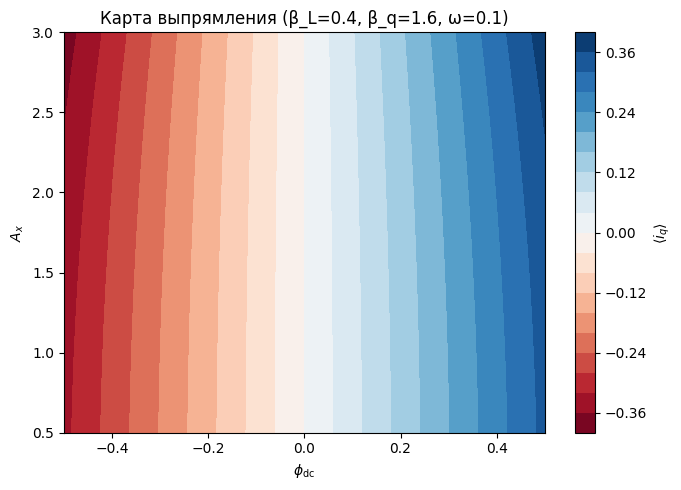

Карта сохранена в rectification_map_dc.png
Iter 0: β_L=0.3975, β_q=1.5991, β_c=0.9000, |<iq>|=0.06806
Iter 1: β_L=0.3950, β_q=1.5982, β_c=0.9000, |<iq>|=0.06829
Iter 2: β_L=0.3925, β_q=1.5973, β_c=0.9000, |<iq>|=0.06853
Iter 3: β_L=0.3899, β_q=1.5964, β_c=0.9000, |<iq>|=0.06877
Iter 4: β_L=0.3874, β_q=1.5954, β_c=0.9000, |<iq>|=0.06902
Iter 5: β_L=0.3848, β_q=1.5945, β_c=0.9000, |<iq>|=0.06926
Iter 6: β_L=0.3822, β_q=1.5936, β_c=0.9000, |<iq>|=0.06951
Iter 7: β_L=0.3796, β_q=1.5926, β_c=0.9000, |<iq>|=0.06977
Iter 8: β_L=0.3769, β_q=1.5917, β_c=0.9000, |<iq>|=0.07002
Iter 9: β_L=0.3743, β_q=1.5907, β_c=0.9000, |<iq>|=0.07028
Iter 10: β_L=0.3716, β_q=1.5898, β_c=0.9000, |<iq>|=0.07055
Iter 11: β_L=0.3689, β_q=1.5888, β_c=0.9000, |<iq>|=0.07082
Iter 12: β_L=0.3662, β_q=1.5878, β_c=0.9000, |<iq>|=0.07109
Iter 13: β_L=0.3635, β_q=1.5869, β_c=0.9000, |<iq>|=0.07136
Iter 14: β_L=0.3608, β_q=1.5859, β_c=0.9000, |<iq>|=0.07164
Iter 15: β_L=0.3580, β_q=1.5849, β_c=0.9001, |<iq>|=0.07193
Iter 16

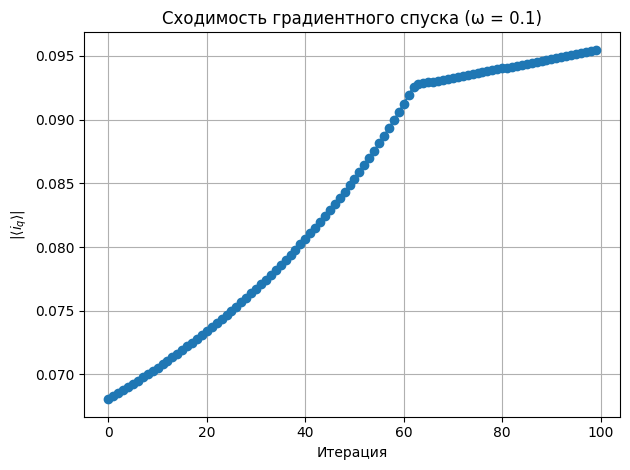

In [3]:
# =============================================================================
# ДЕМОНСТРАЦИЯ
# =============================================================================
if __name__ == "__main__":
    # 1. Строим карту выпрямления (β_c=0)
    plot_rectification_map_dc(beta_L=0.4, beta_q=1.6, omega=0.1)

    # 2. Оптимизация градиентным спуском (β_c варьируется)
    init = [0.4, 1.6, 0.9, 1.5, 0.1, 0.1, 0.0]   # β_L,β_q,β_c,A_x,ω,φ_dc,φ_in
    opt_params, hist = gradient_descent(init, lr=0.03, delta=0.05, max_iter=100)

    print("\nОптимальные параметры (β_L, β_q, β_c, A_x, ω=0.1, φ_dc, φ_in=0):")
    print([f"{opt_params[i]:.4f}" for i in range(7)])
    print(f"Достигнутое |<iq>| = {hist[-1]:.5f}")

    # График сходимости
    plt.figure()
    plt.plot(hist, 'o-')
    plt.xlabel('Итерация')
    plt.ylabel(r'$|\langle i_q \rangle|$')
    plt.title('Сходимость градиентного спуска (ω = 0.1)')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('convergence.png', dpi=150)
    plt.show()

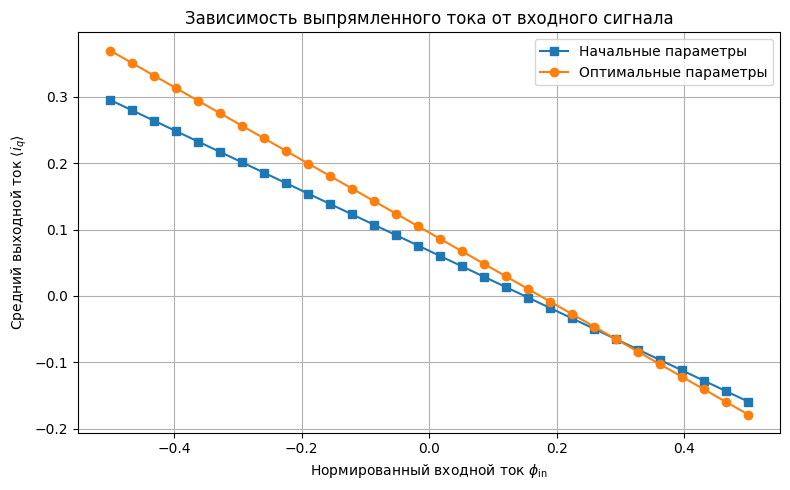

In [7]:

if __name__ == "__main__":
  phi_in_vals = np.linspace(-0.5, 0.5, 30)

  # а) с начальными параметрами
  init_params = (0.4, 1.6, 0.9, 1.5, 0.1, 0.1, 0.0)
  avg_init = []
  for phi_in in phi_in_vals:
      p = list(init_params)
      p[6] = phi_in
      avg_init.append(simulate_and_average_c(tuple(p), n_periods=50))

  # б) с оптимальными параметрами
  avg_opt = []
  for phi_in in phi_in_vals:
      p = list(opt_params)
      p[6] = phi_in
      avg_opt.append(simulate_and_average_c(tuple(p), n_periods=50))

  # Построение графика
  plt.figure(figsize=(8,5))
  plt.plot(phi_in_vals, avg_init, 's-', label='Начальные параметры')
  plt.plot(phi_in_vals, avg_opt, 'o-', label='Оптимальные параметры')
  plt.xlabel(r'Нормированный входной ток $\phi_{\mathrm{in}}$')
  plt.ylabel(r'Средний выходной ток $\langle i_q \rangle$')
  plt.title('Зависимость выпрямленного тока от входного сигнала')
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.savefig('avg_iq_vs_phi_in.png', dpi=150)
  plt.show()